# Pancake hidden-state trajectory analysis

2026-08-27夜間実行。layer 48、6実在条件、各100 trial。

In [1]:
import csv
import json
from pathlib import Path
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'data_access').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'data_access').is_dir():
    raise RuntimeError('repository rootが見つかりません')
ANALYSIS_DIR = REPO_ROOT / 'results/pancake_2026-08-27_overnight'
FIGURE_DIR = ANALYSIS_DIR / 'figures'
TABLE_DIR = ANALYSIS_DIR / 'tables'
summary = json.loads((ANALYSIS_DIR / 'analysis_summary.json').read_text(encoding='utf-8'))
print('Trials:', summary['trial_count'])
print('Cells:', ', '.join(summary['cells']))
print('Empty cells:', ', '.join(summary['empty_cells']))

Trials: 600
Cells: N3_mm3, N4_mm3, N4_mm4, N5_mm3, N5_mm4, N5_mm5
Empty cells: N3_mm4, N3_mm5, N4_mm5


## 1. データの全体像

空の3マスは欠損ではなく、その `(N, min_moves)` の状態が存在しない。

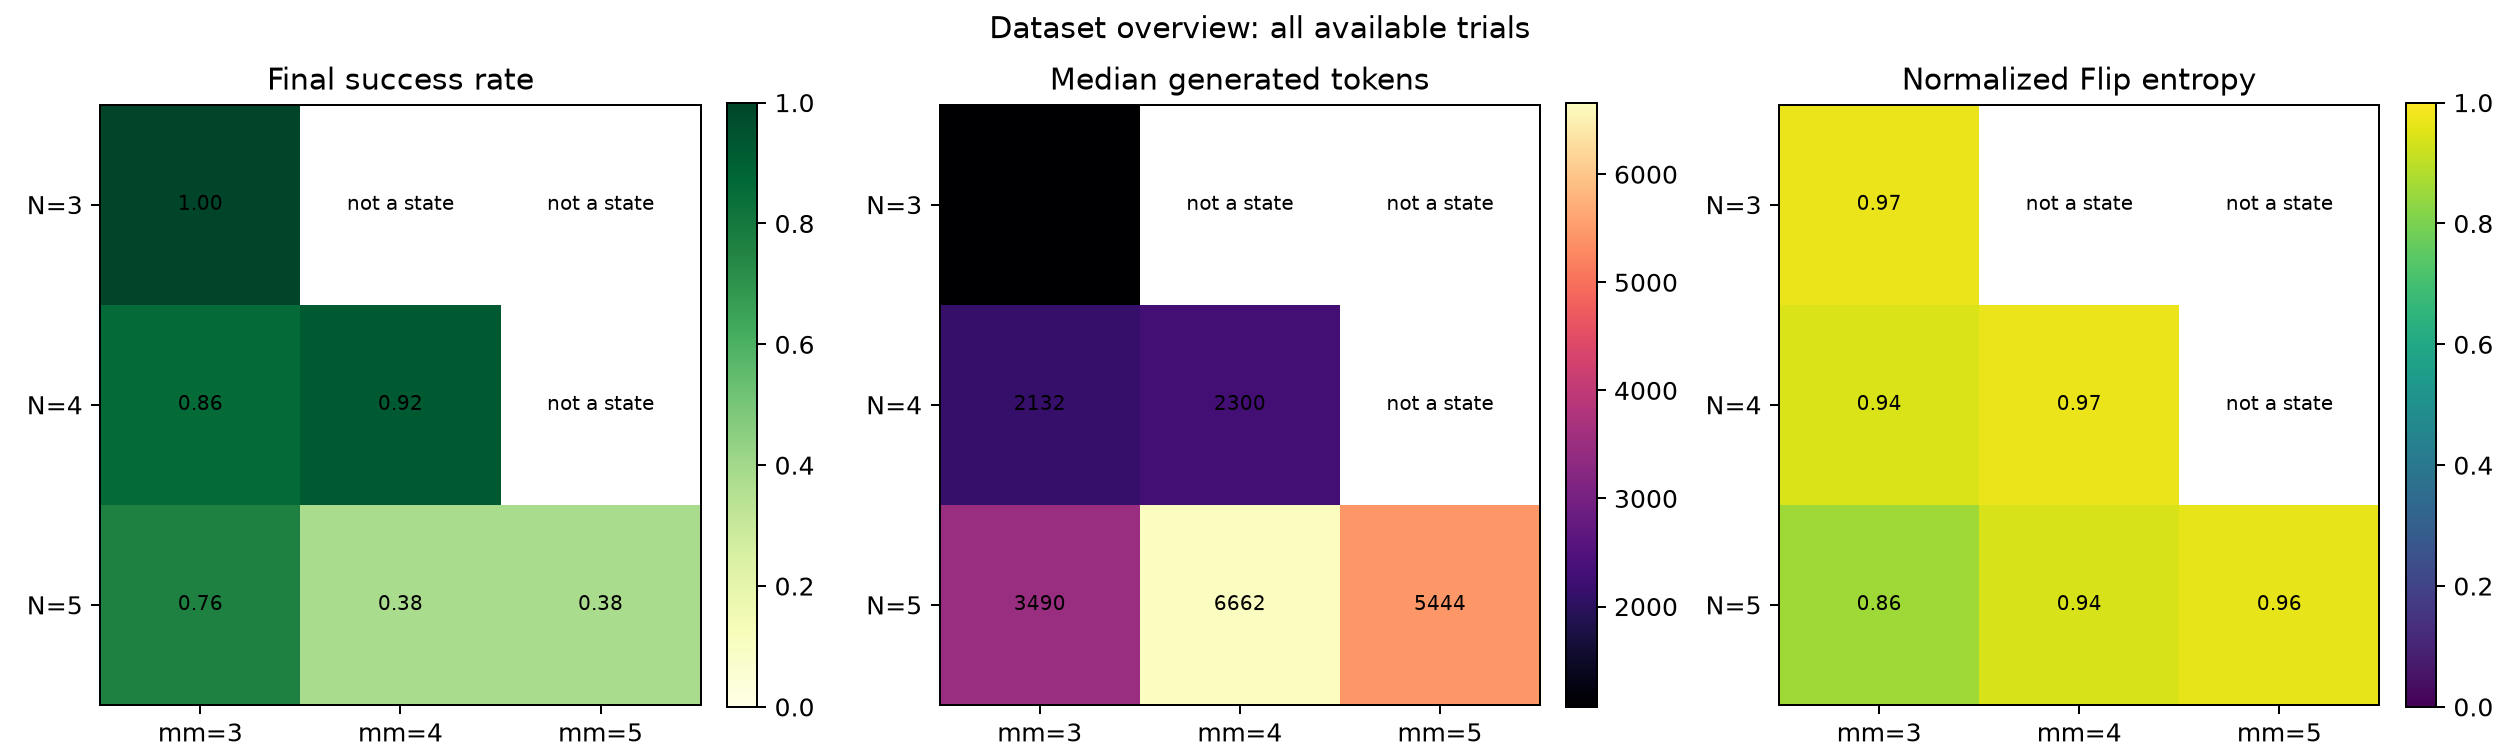

| condition | success | median tokens | Flip entropy |
|---|---:|---:|---:|
| N3_mm3 | 100% | 1072 | 0.97 |
| N4_mm3 | 86% | 2132 | 0.94 |
| N4_mm4 | 92% | 2300 | 0.97 |
| N5_mm3 | 76% | 3490 | 0.86 |
| N5_mm4 | 38% | 6662 | 0.94 |
| N5_mm5 | 38% | 5444 | 0.96 |


In [2]:
display(Image(filename=str(FIGURE_DIR / '01_dataset_overview.png'), width=1100))
rows = summary['condition_summary']
text = '| condition | success | median tokens | Flip entropy |\n|---|---:|---:|---:|\n'
for row in rows:
    text += f"| {row['cell_id']} | {row['success_rate']:.0%} | {row['median_tokens']:.0f} | {row['mean_flip_entropy_normalized']:.2f} |\n"
display(Markdown(text))

## 2. PCA

各trialから同数の32時点を取り、条件内・全条件・同一N・同一min_movesごとに共有基底をfitした。累積説明分散90%まで、最大50成分。3次元図はPC1–3だけだが、距離指標は選択された全成分を使う。

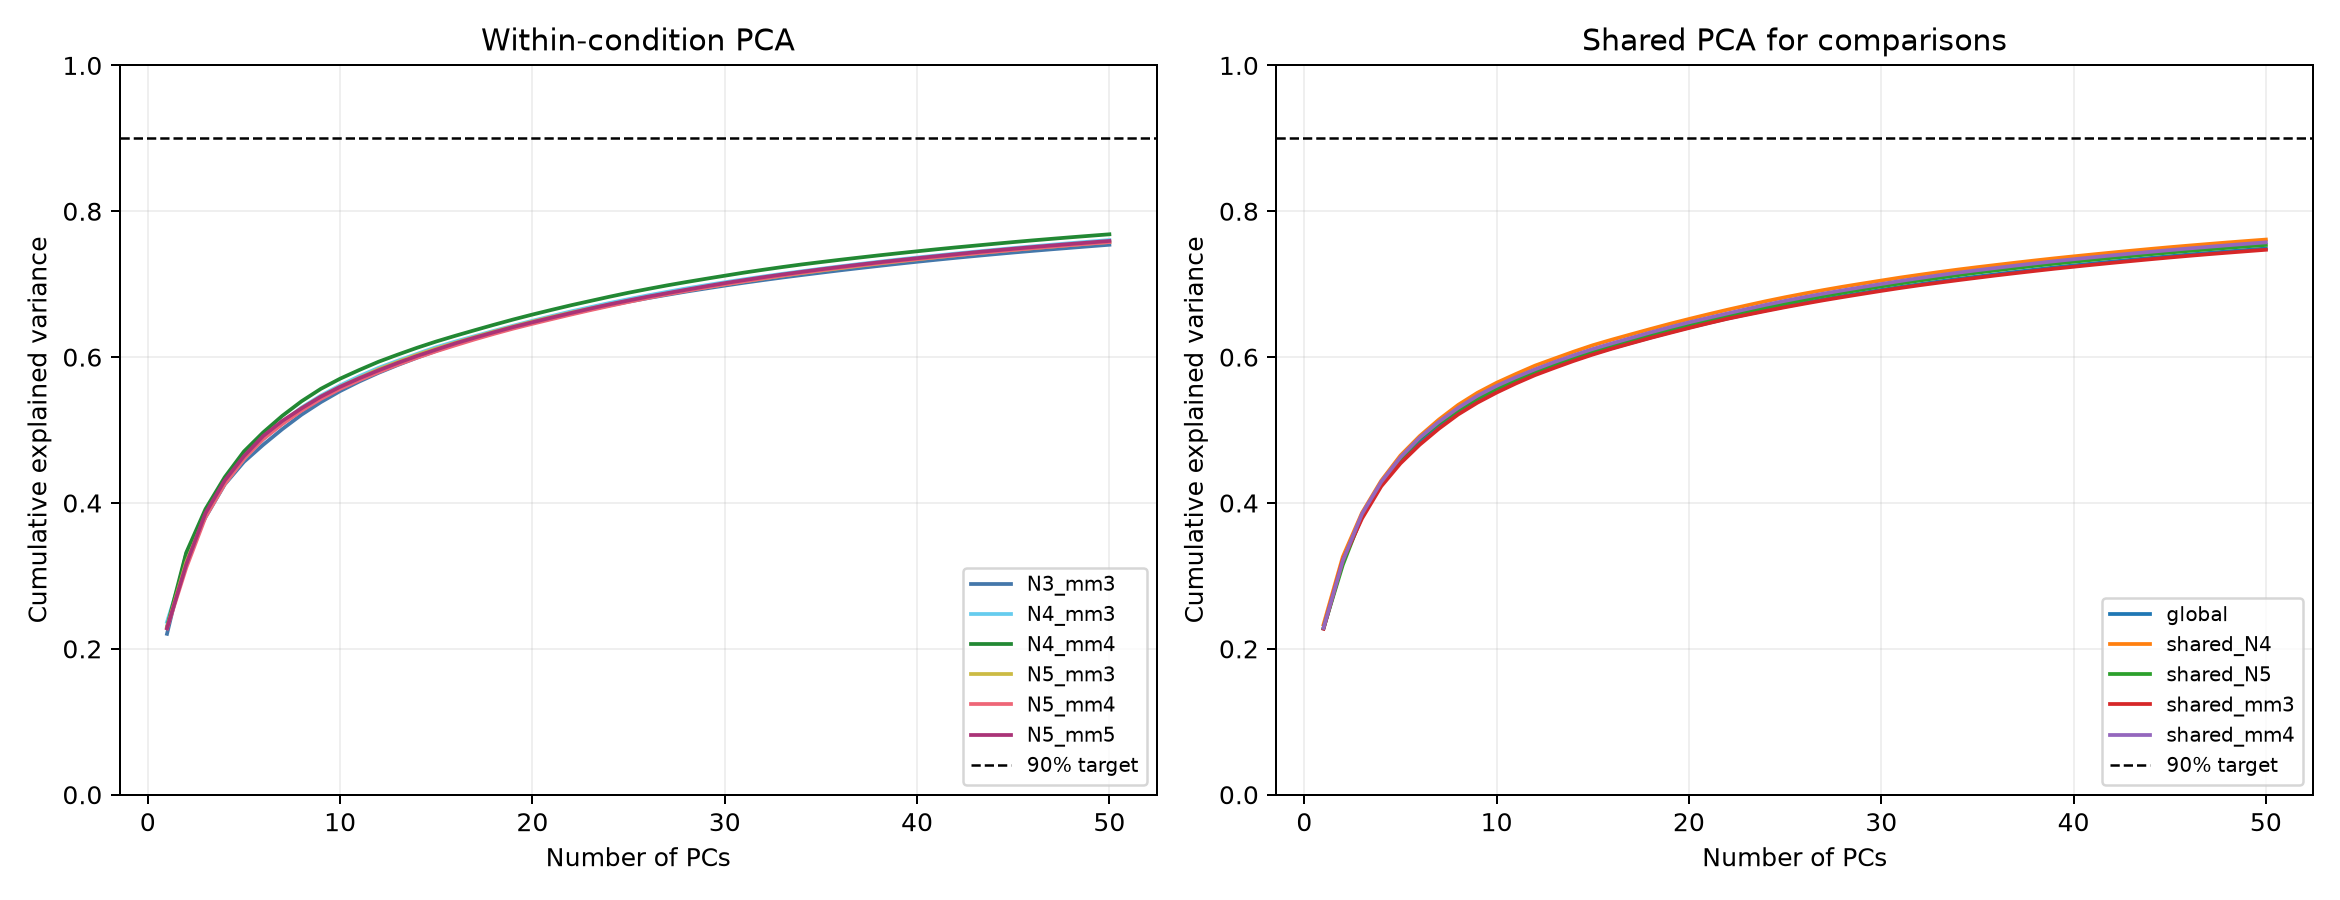

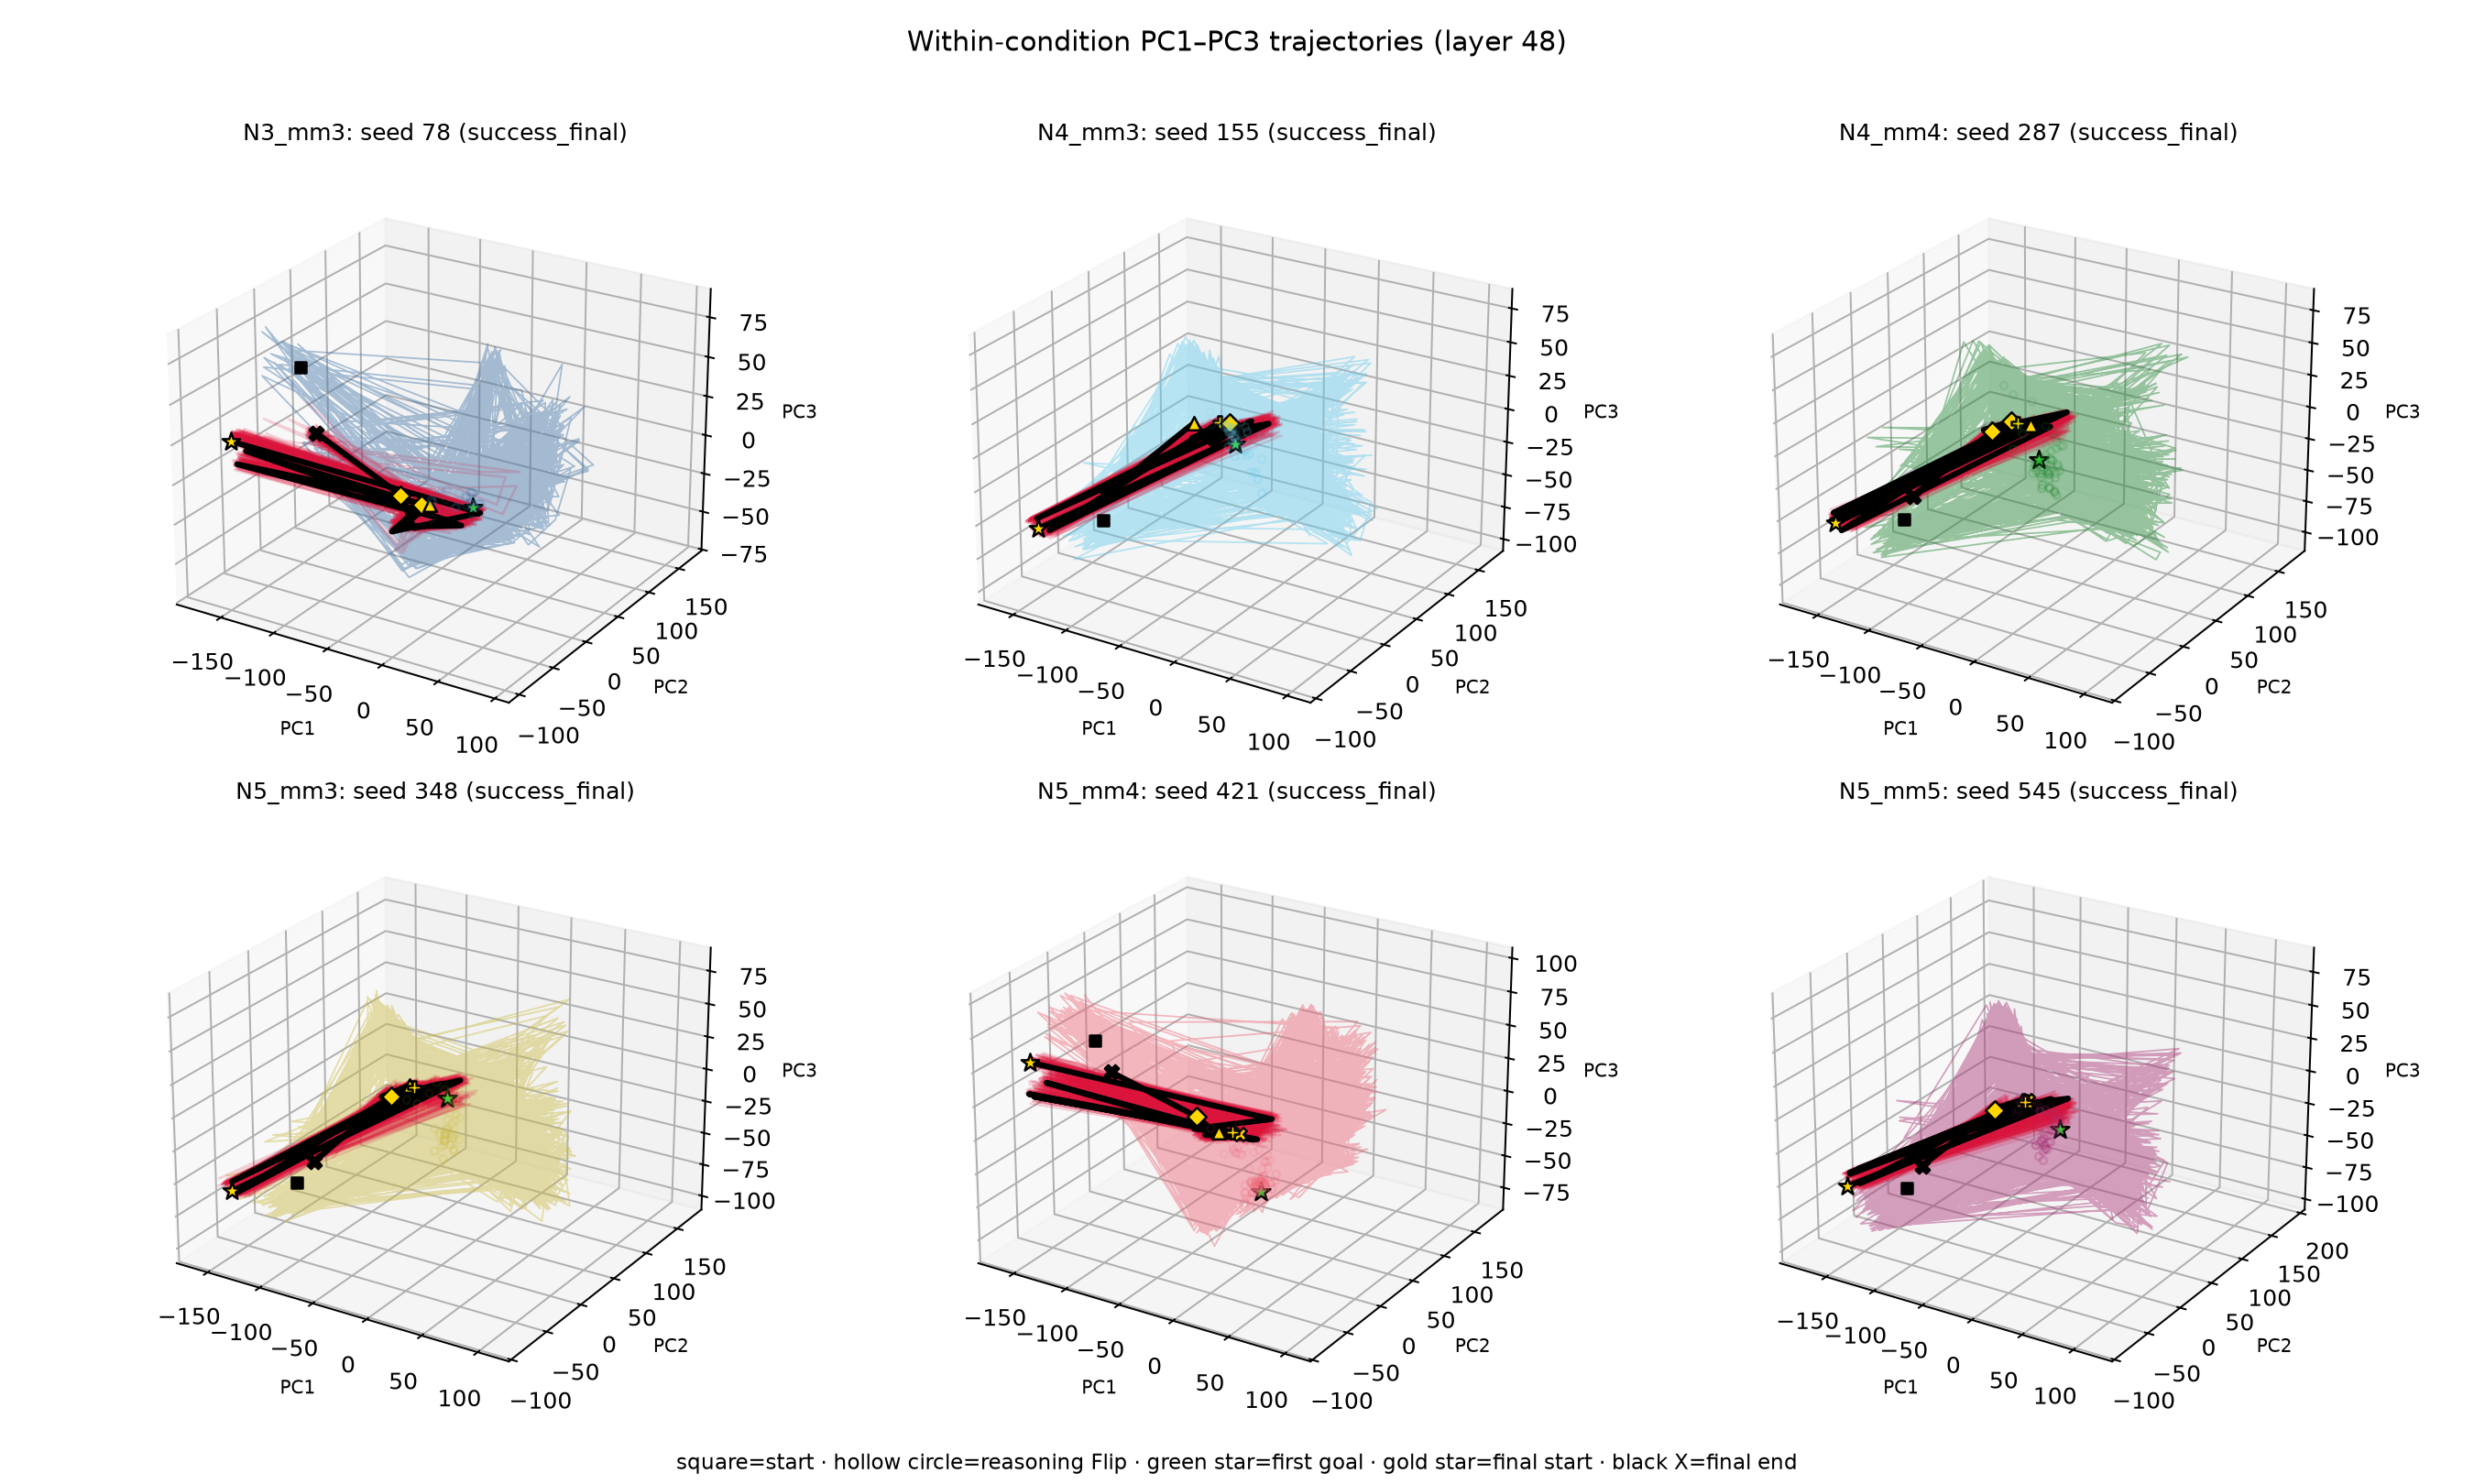

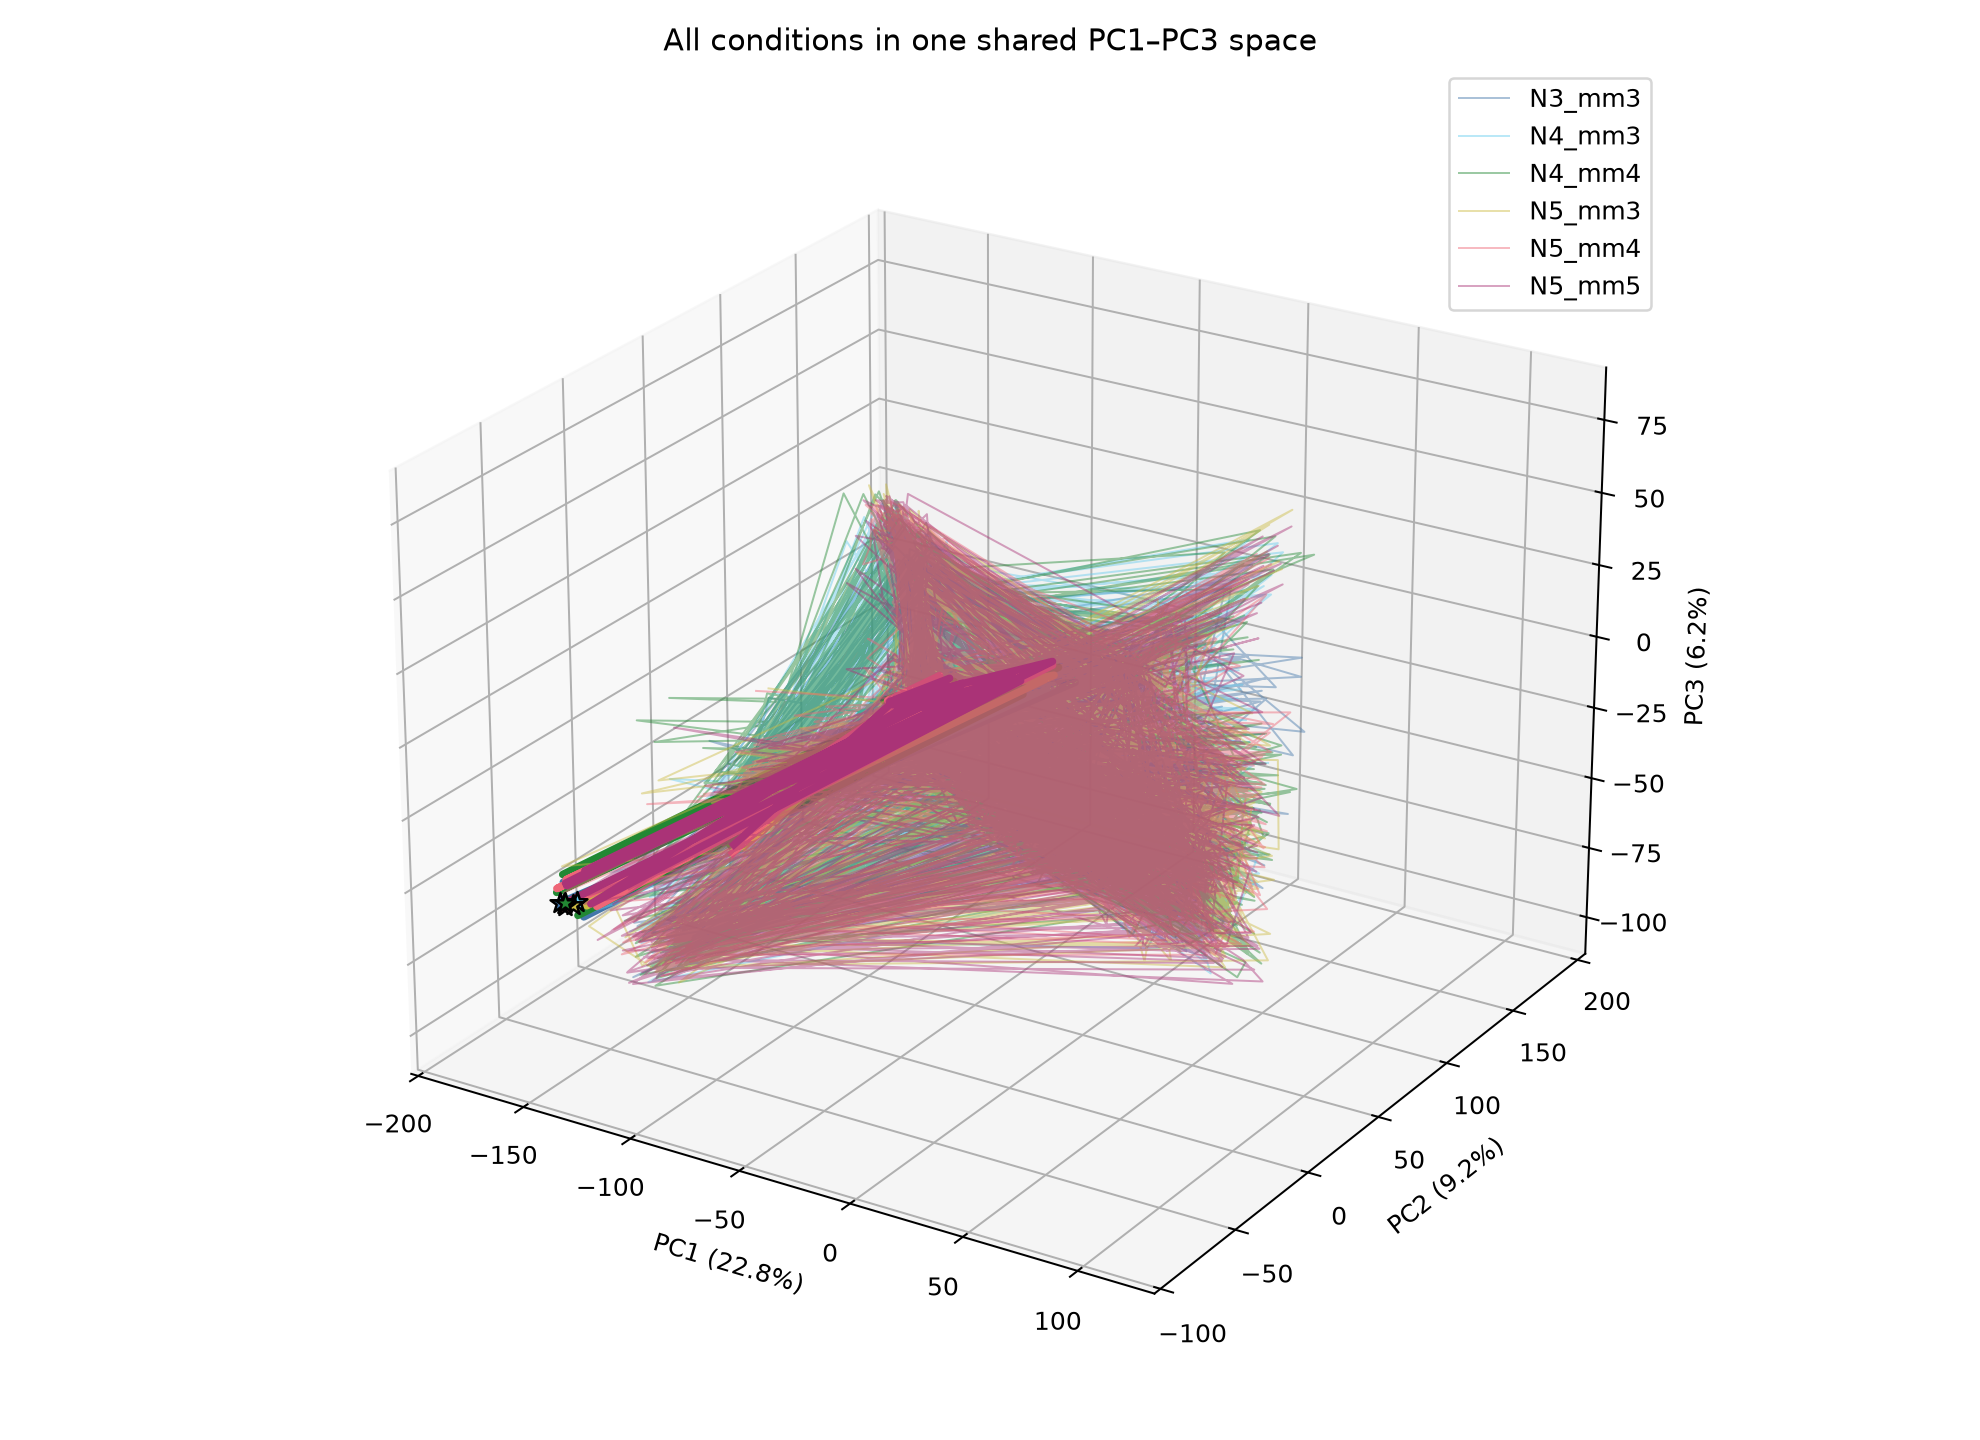

In [3]:
for name in ['02_pca_explained_variance.png', '03_within_condition_pc123.png', '04_global_shared_pc123.png']:
    display(Image(filename=str(FIGURE_DIR / name), width=1100))

## 3. Finalization corridor

同長finalは元の5120次元aligned cosine、異長曲線は共有PCA上の離散Fréchet距離で比較する。random reasoning windowとleave-one-trial-out corridor距離を対照にした。

| condition | final cosine | null 99% | distance drop |
|---|---:|---:|---:|
| N3_mm3 | 0.934 | 0.470 | -0.072 |
| N4_mm3 | 0.915 | 0.480 | -0.003 |
| N4_mm4 | 0.917 | 0.466 | -0.016 |
| N5_mm3 | 0.903 | 0.492 | +0.003 |
| N5_mm4 | 0.897 | 0.468 | -0.002 |
| N5_mm5 | 0.900 | 0.456 | -0.038 |


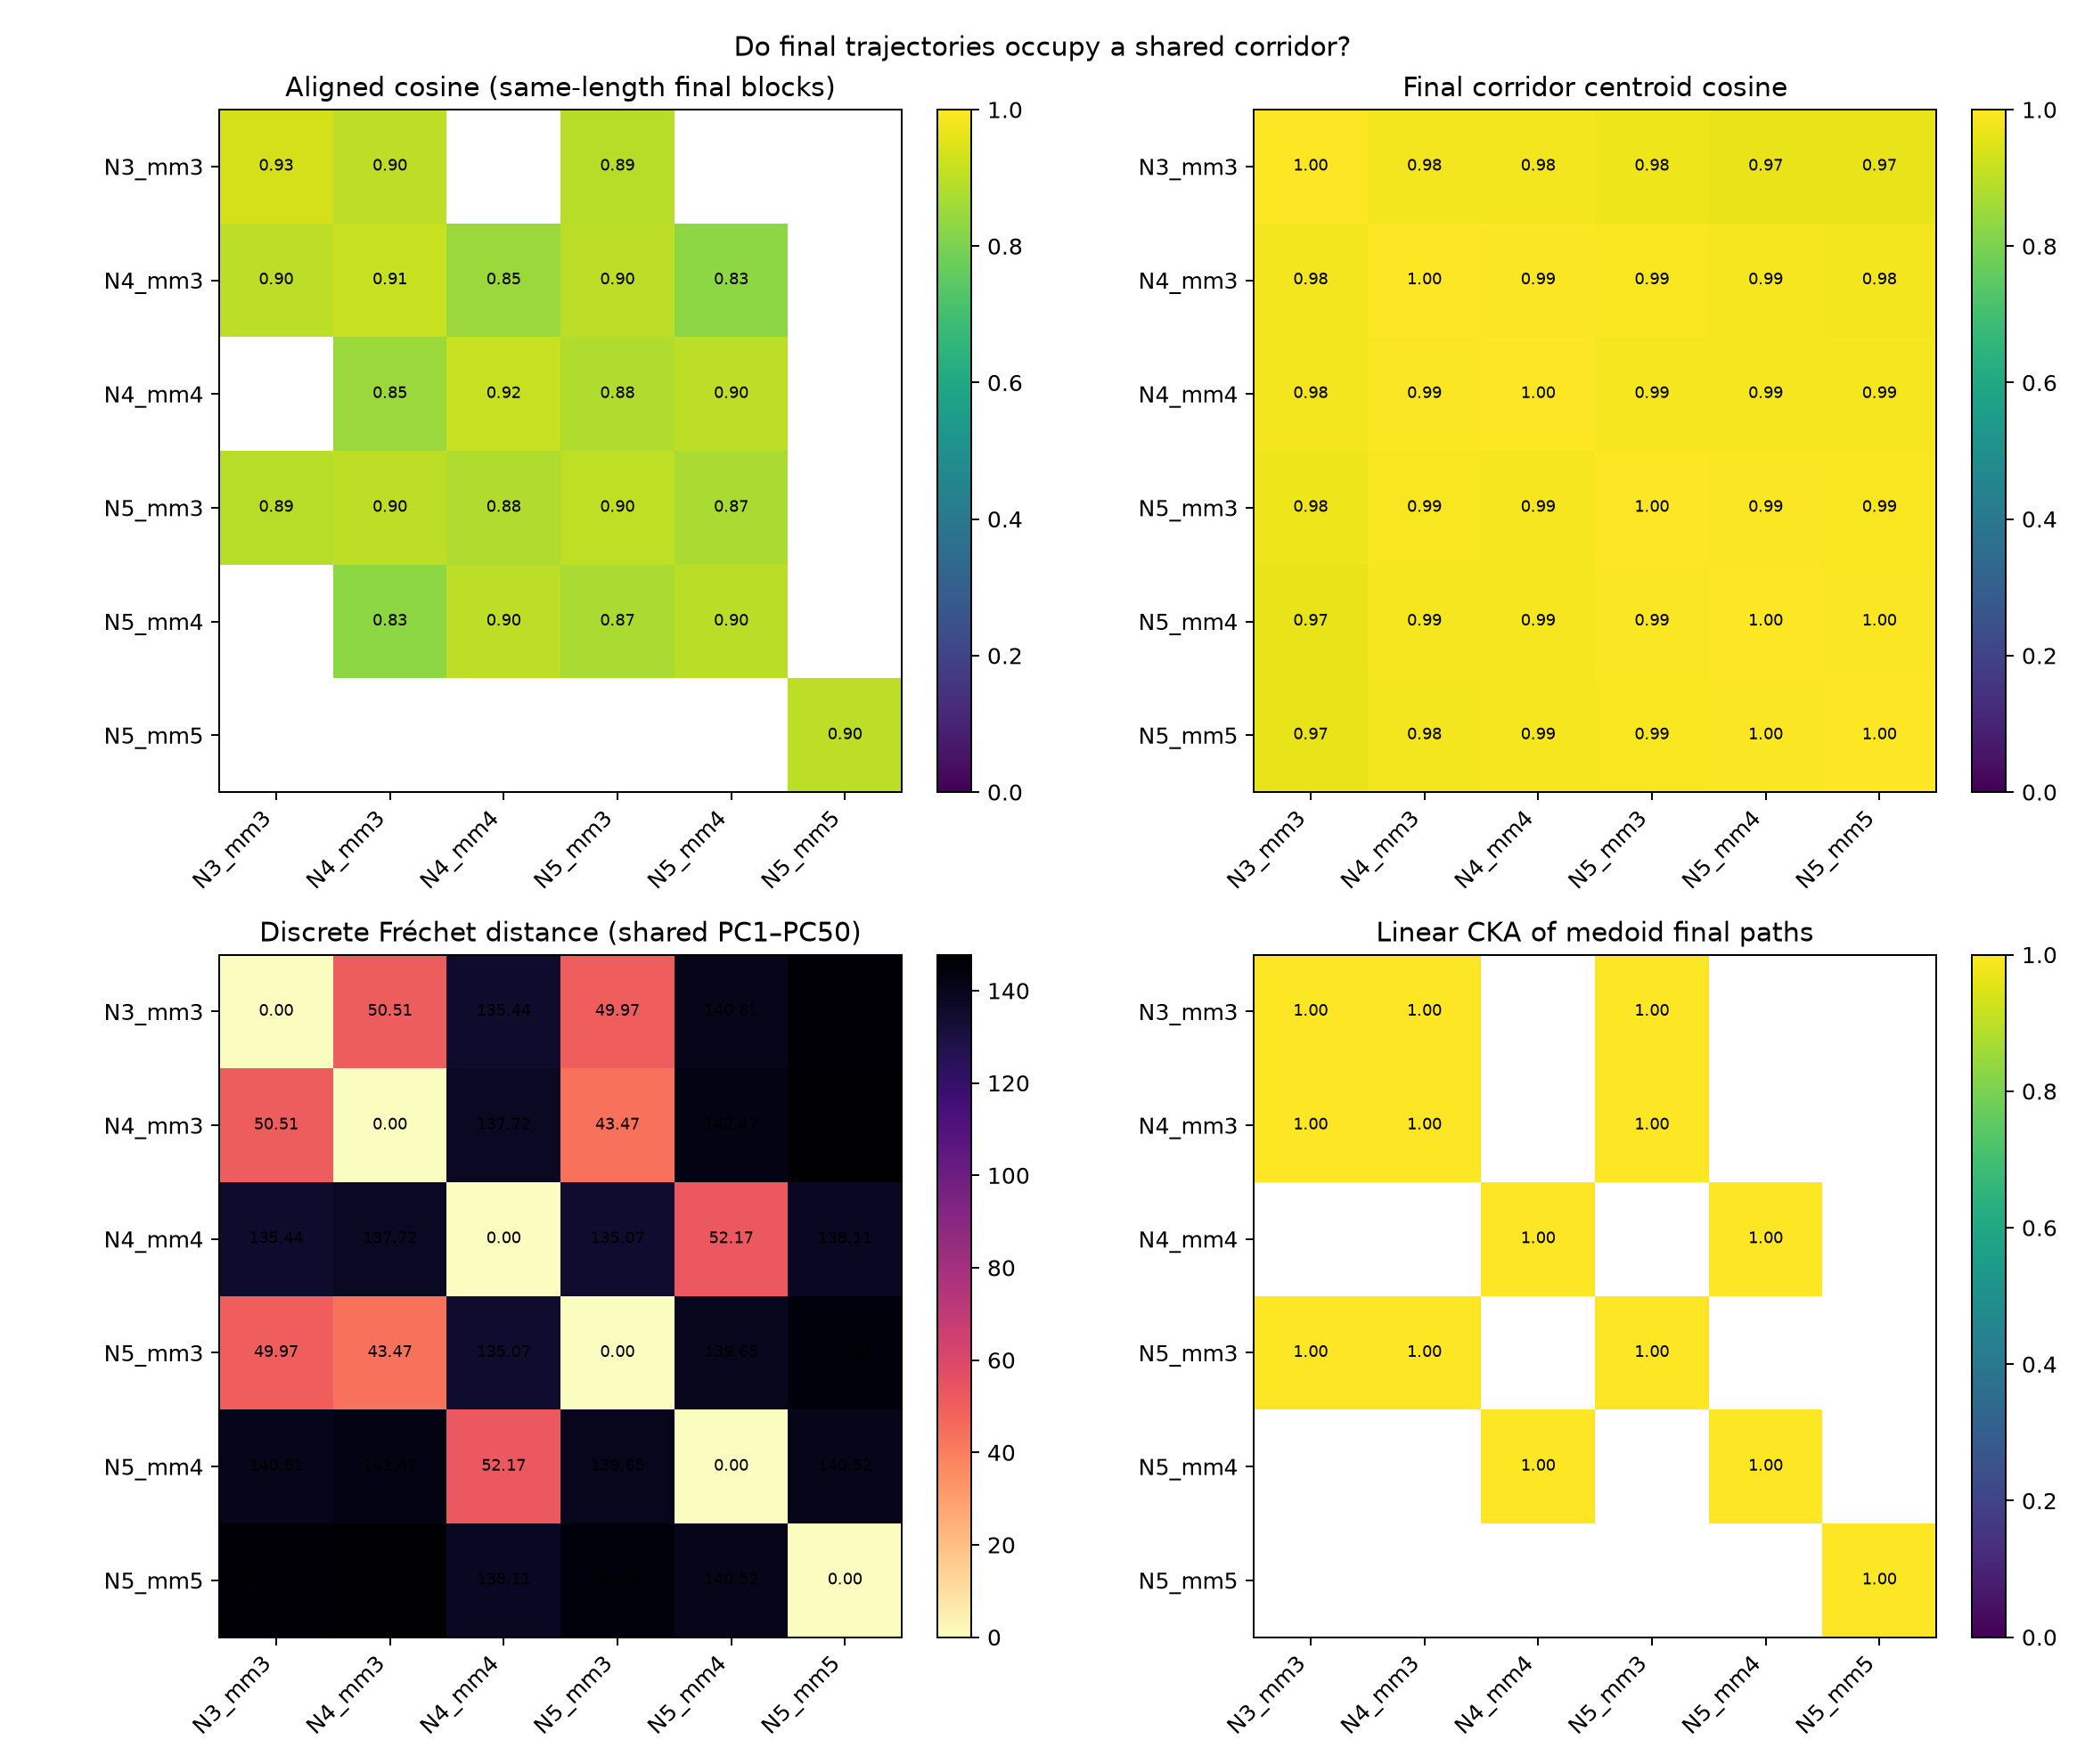

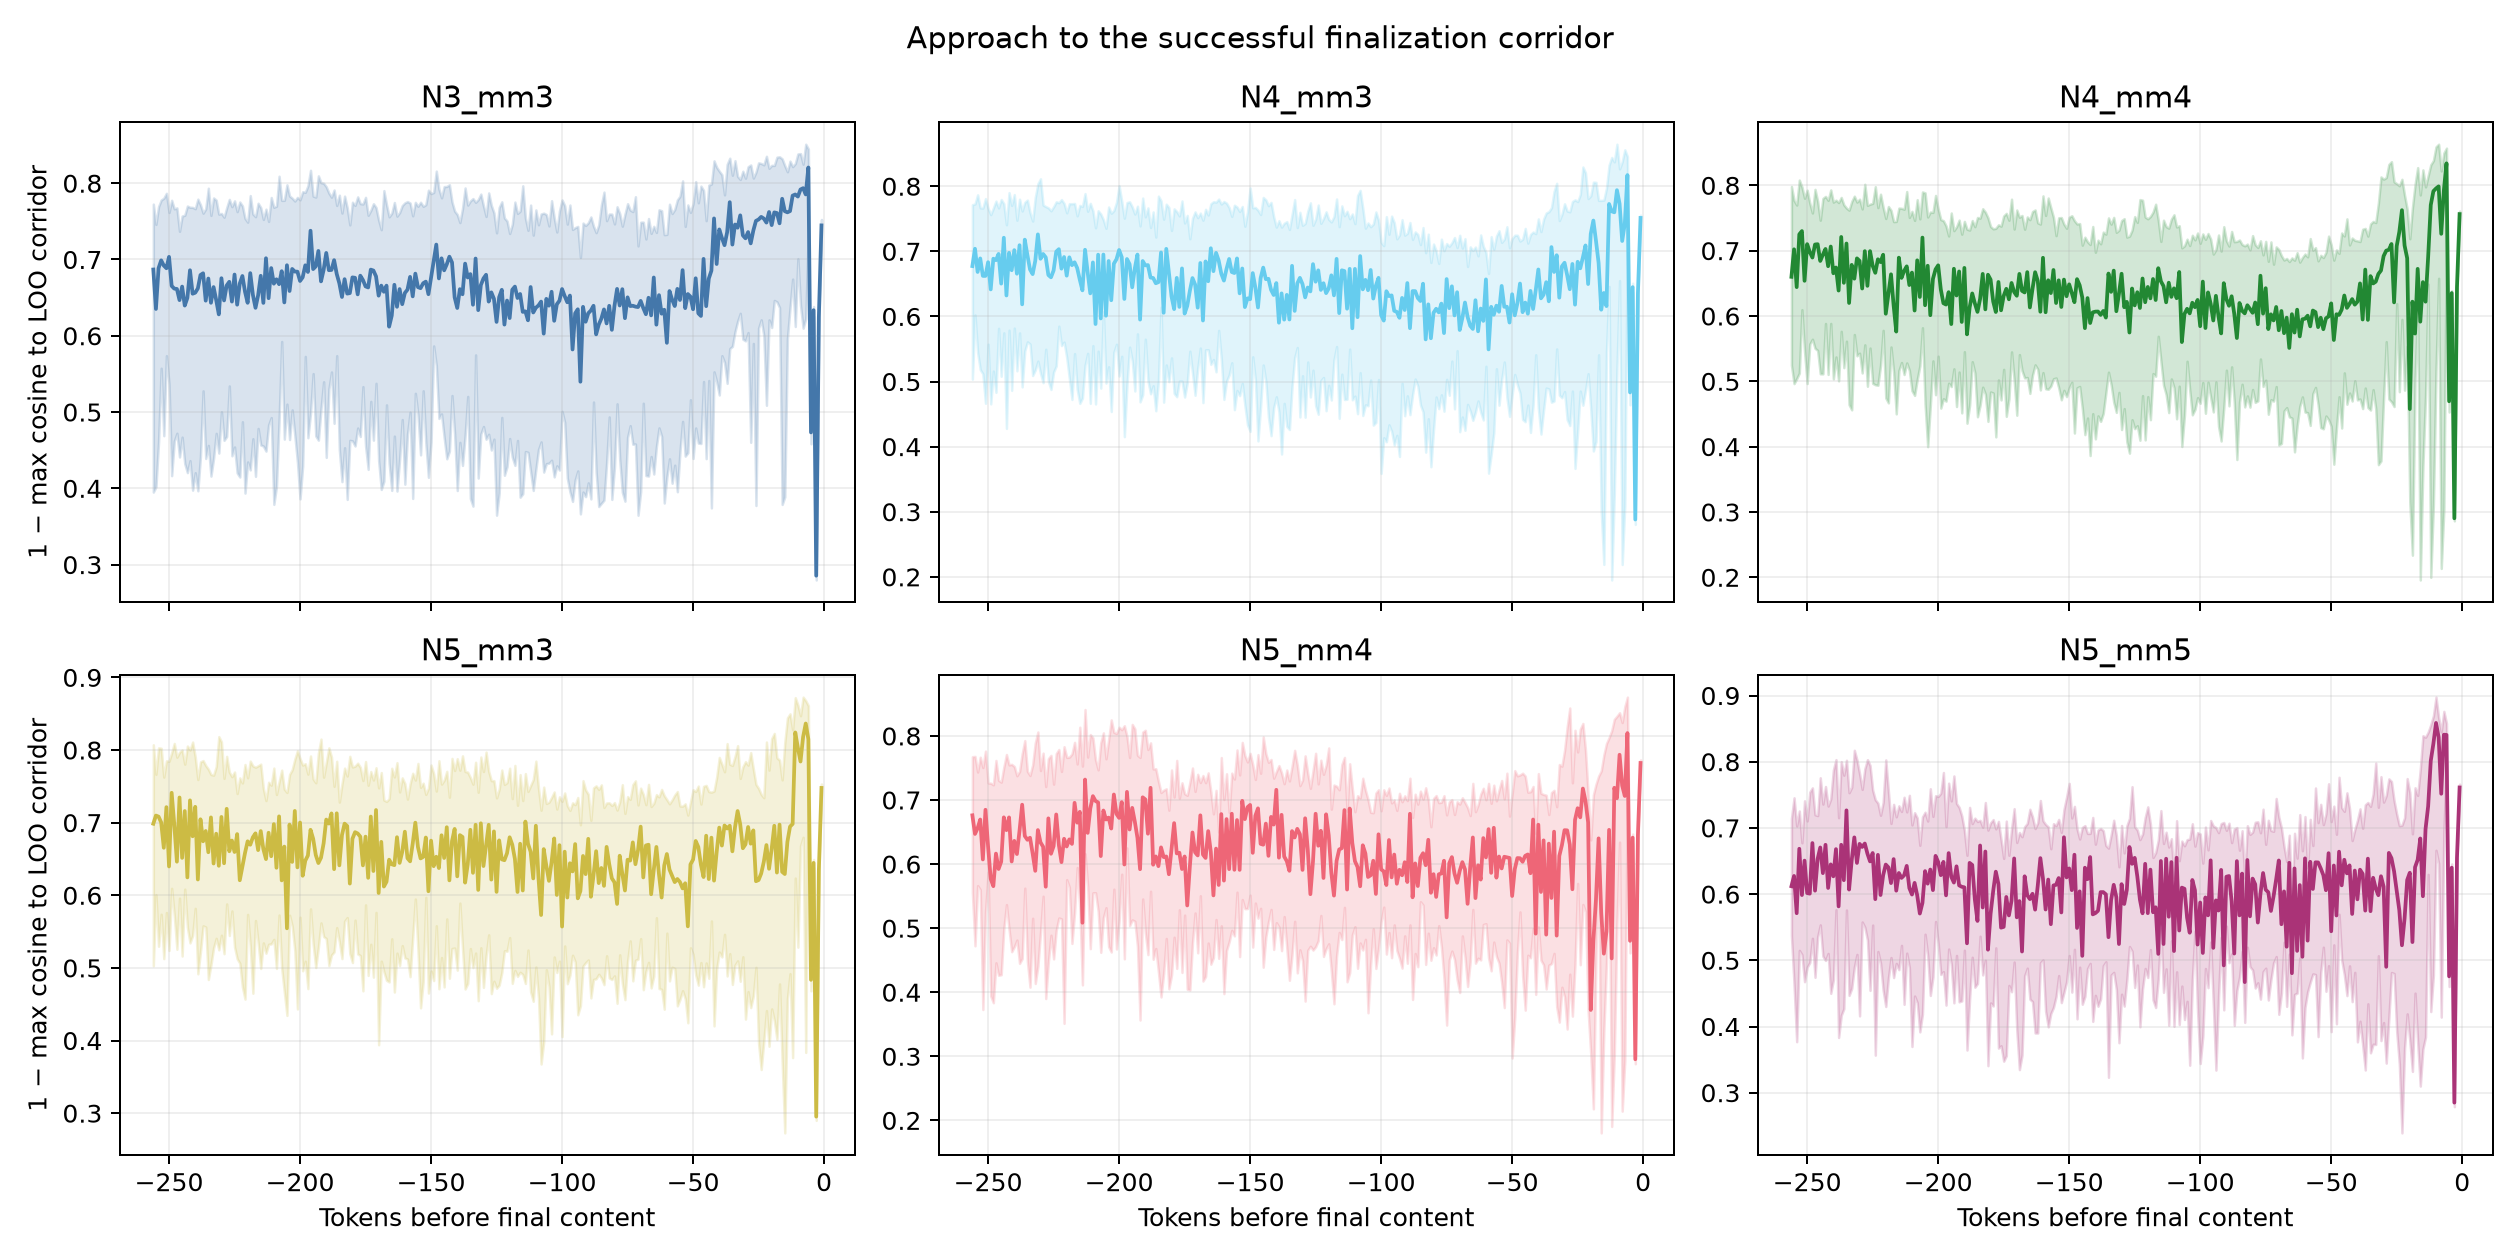

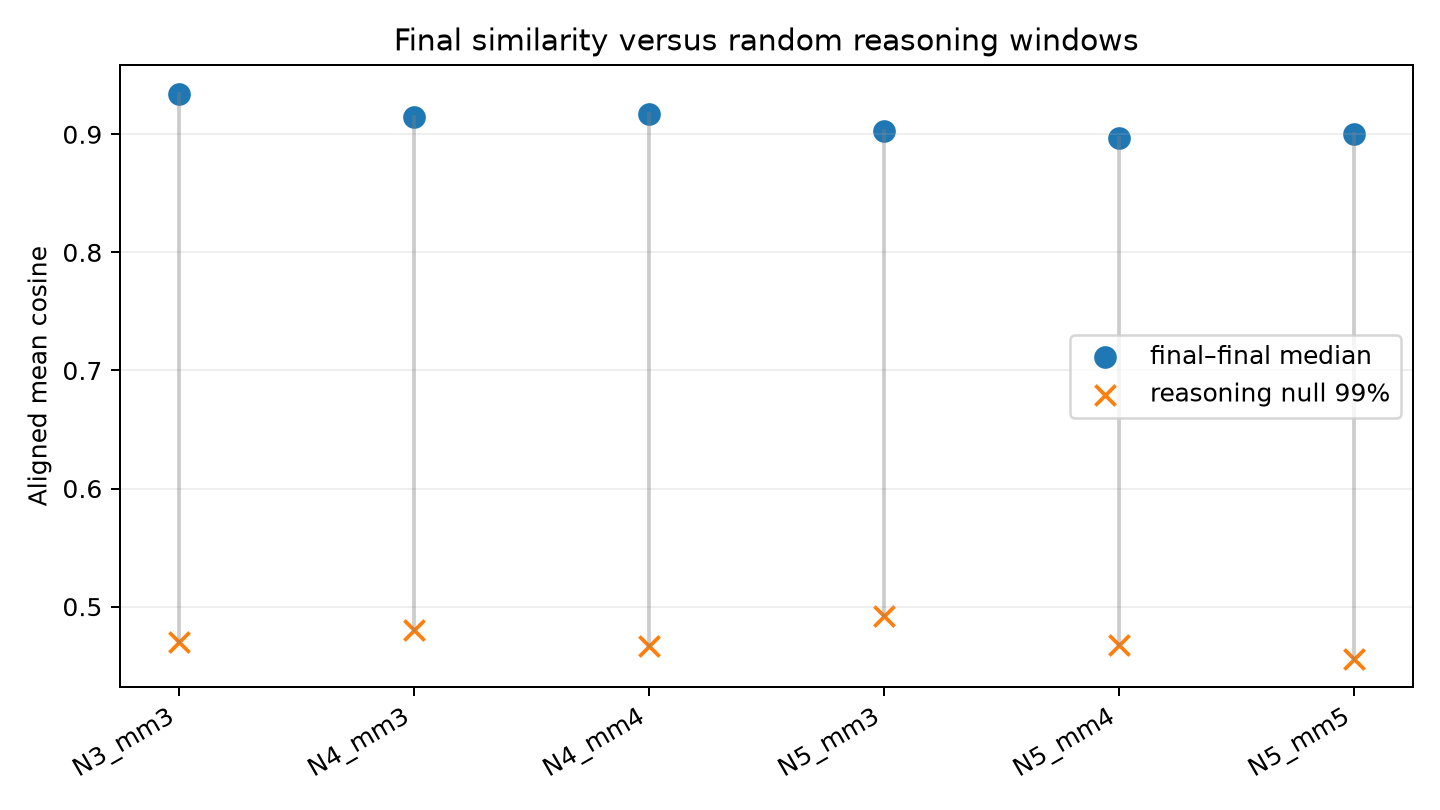

In [4]:
text = '| condition | final cosine | null 99% | distance drop |\n|---|---:|---:|---:|\n'
for row in summary['corridor_metrics']:
    text += f"| {row['cell_id']} | {row['final_aligned_cosine_median']:.3f} | {row['reasoning_null_q99']:.3f} | {row['corridor_distance_drop']:+.3f} |\n"
display(Markdown(text))
for name in ['05_final_similarity_heatmaps.png', '06_corridor_approach.png', '07_final_vs_reasoning_null.png']:
    display(Image(filename=str(FIGURE_DIR / name), width=1100))

## 4. 探索複雑度

`N!`, `(N-1)^min_moves`, 厳密なdistance-shell state数に加え、debug replayからFlip生成entropy・訪問状態entropy・反復率を算出した。6条件だけなので相関は記述的に読む。

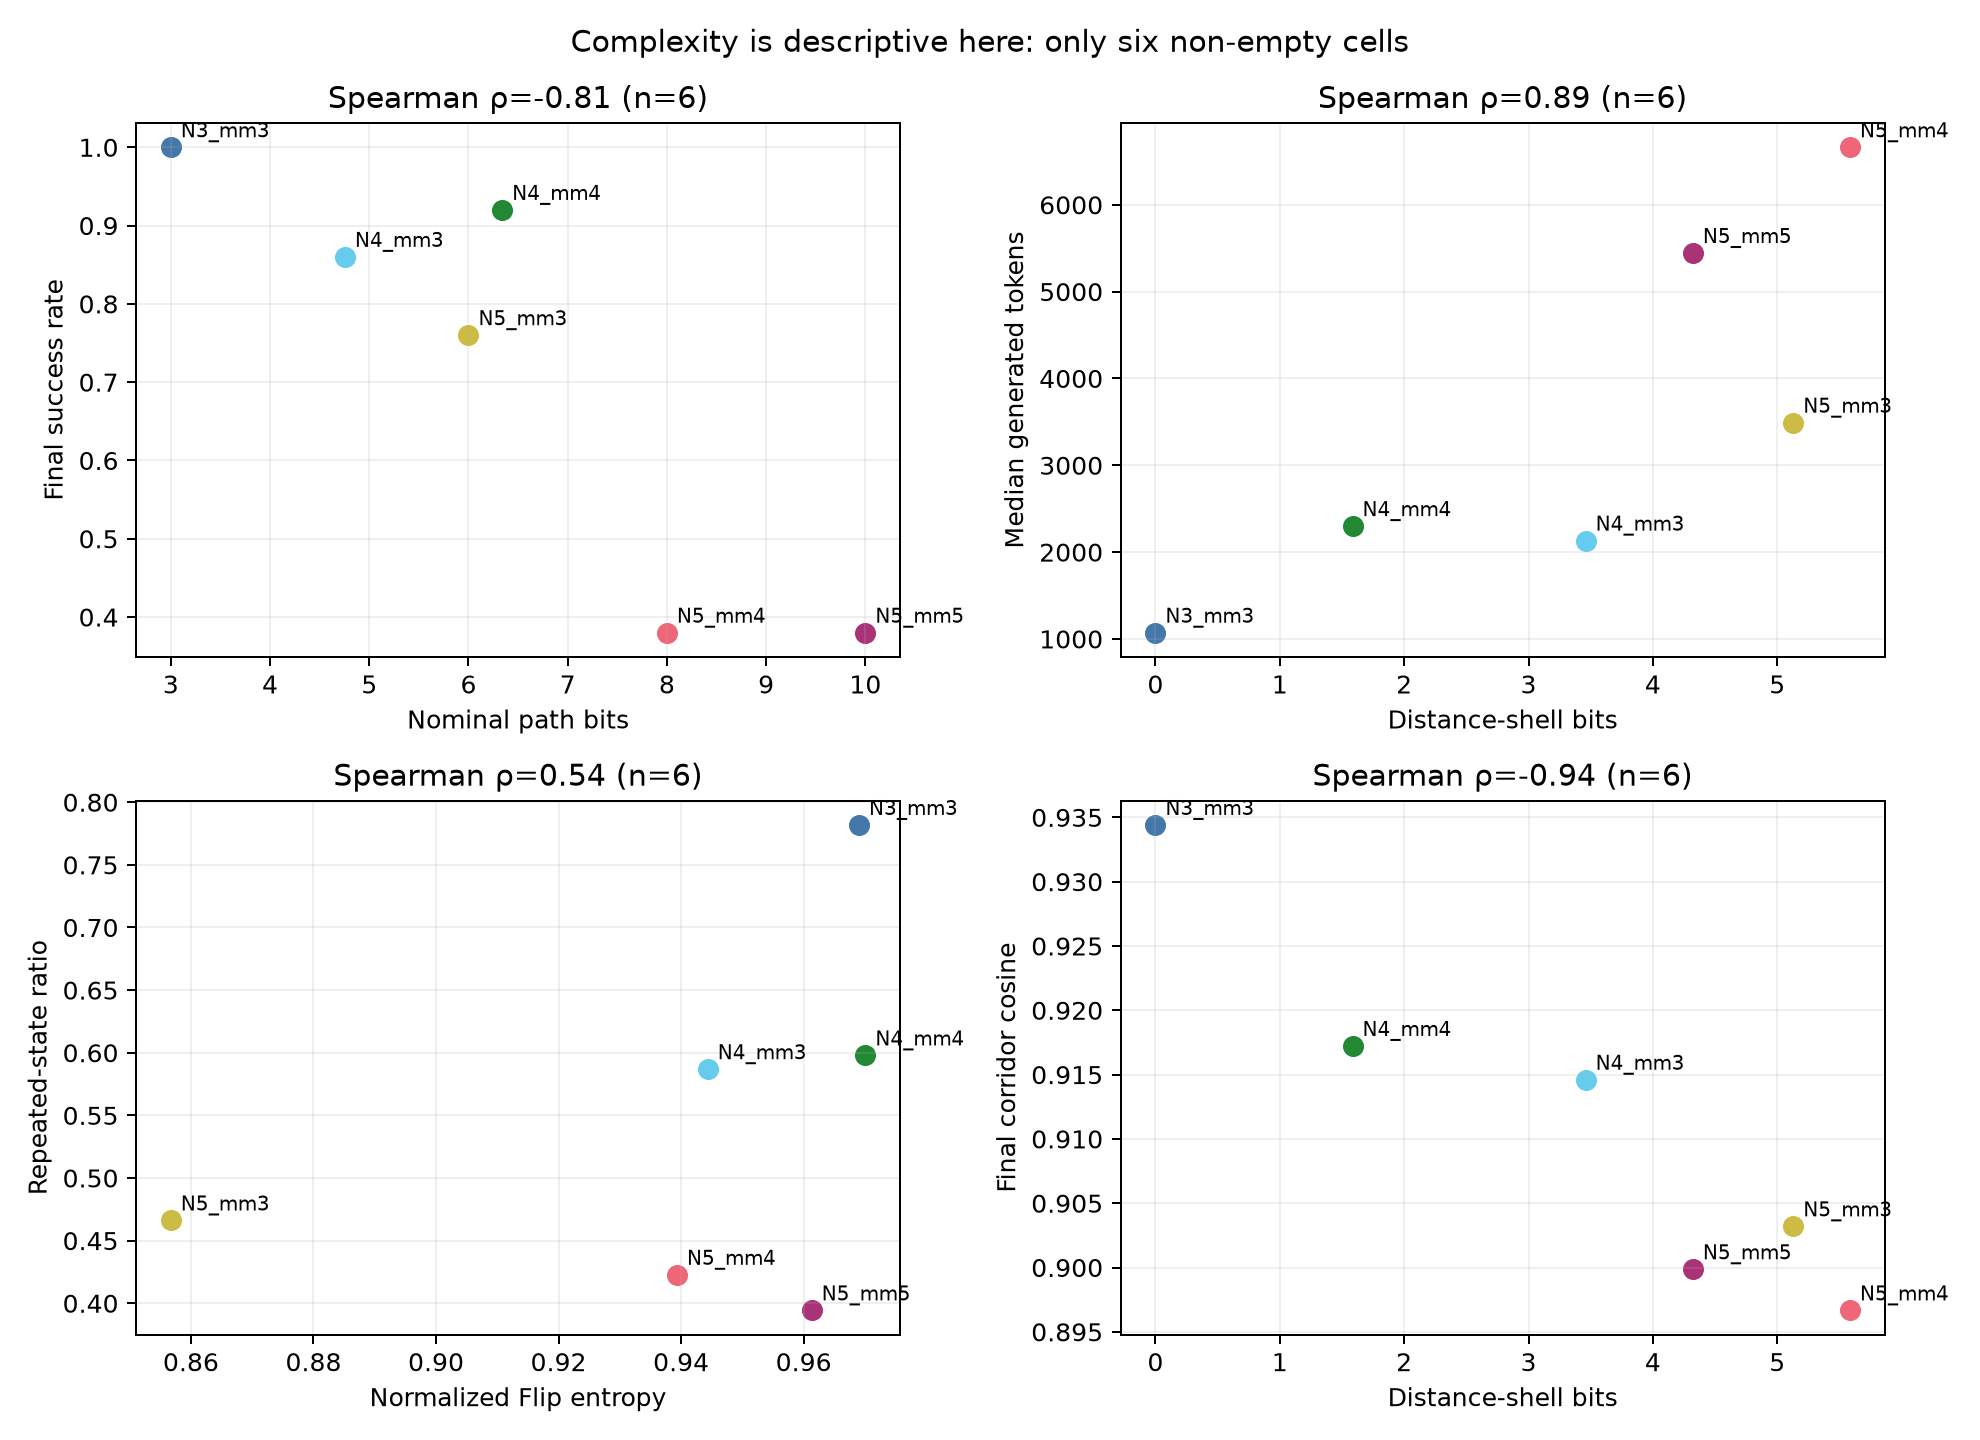

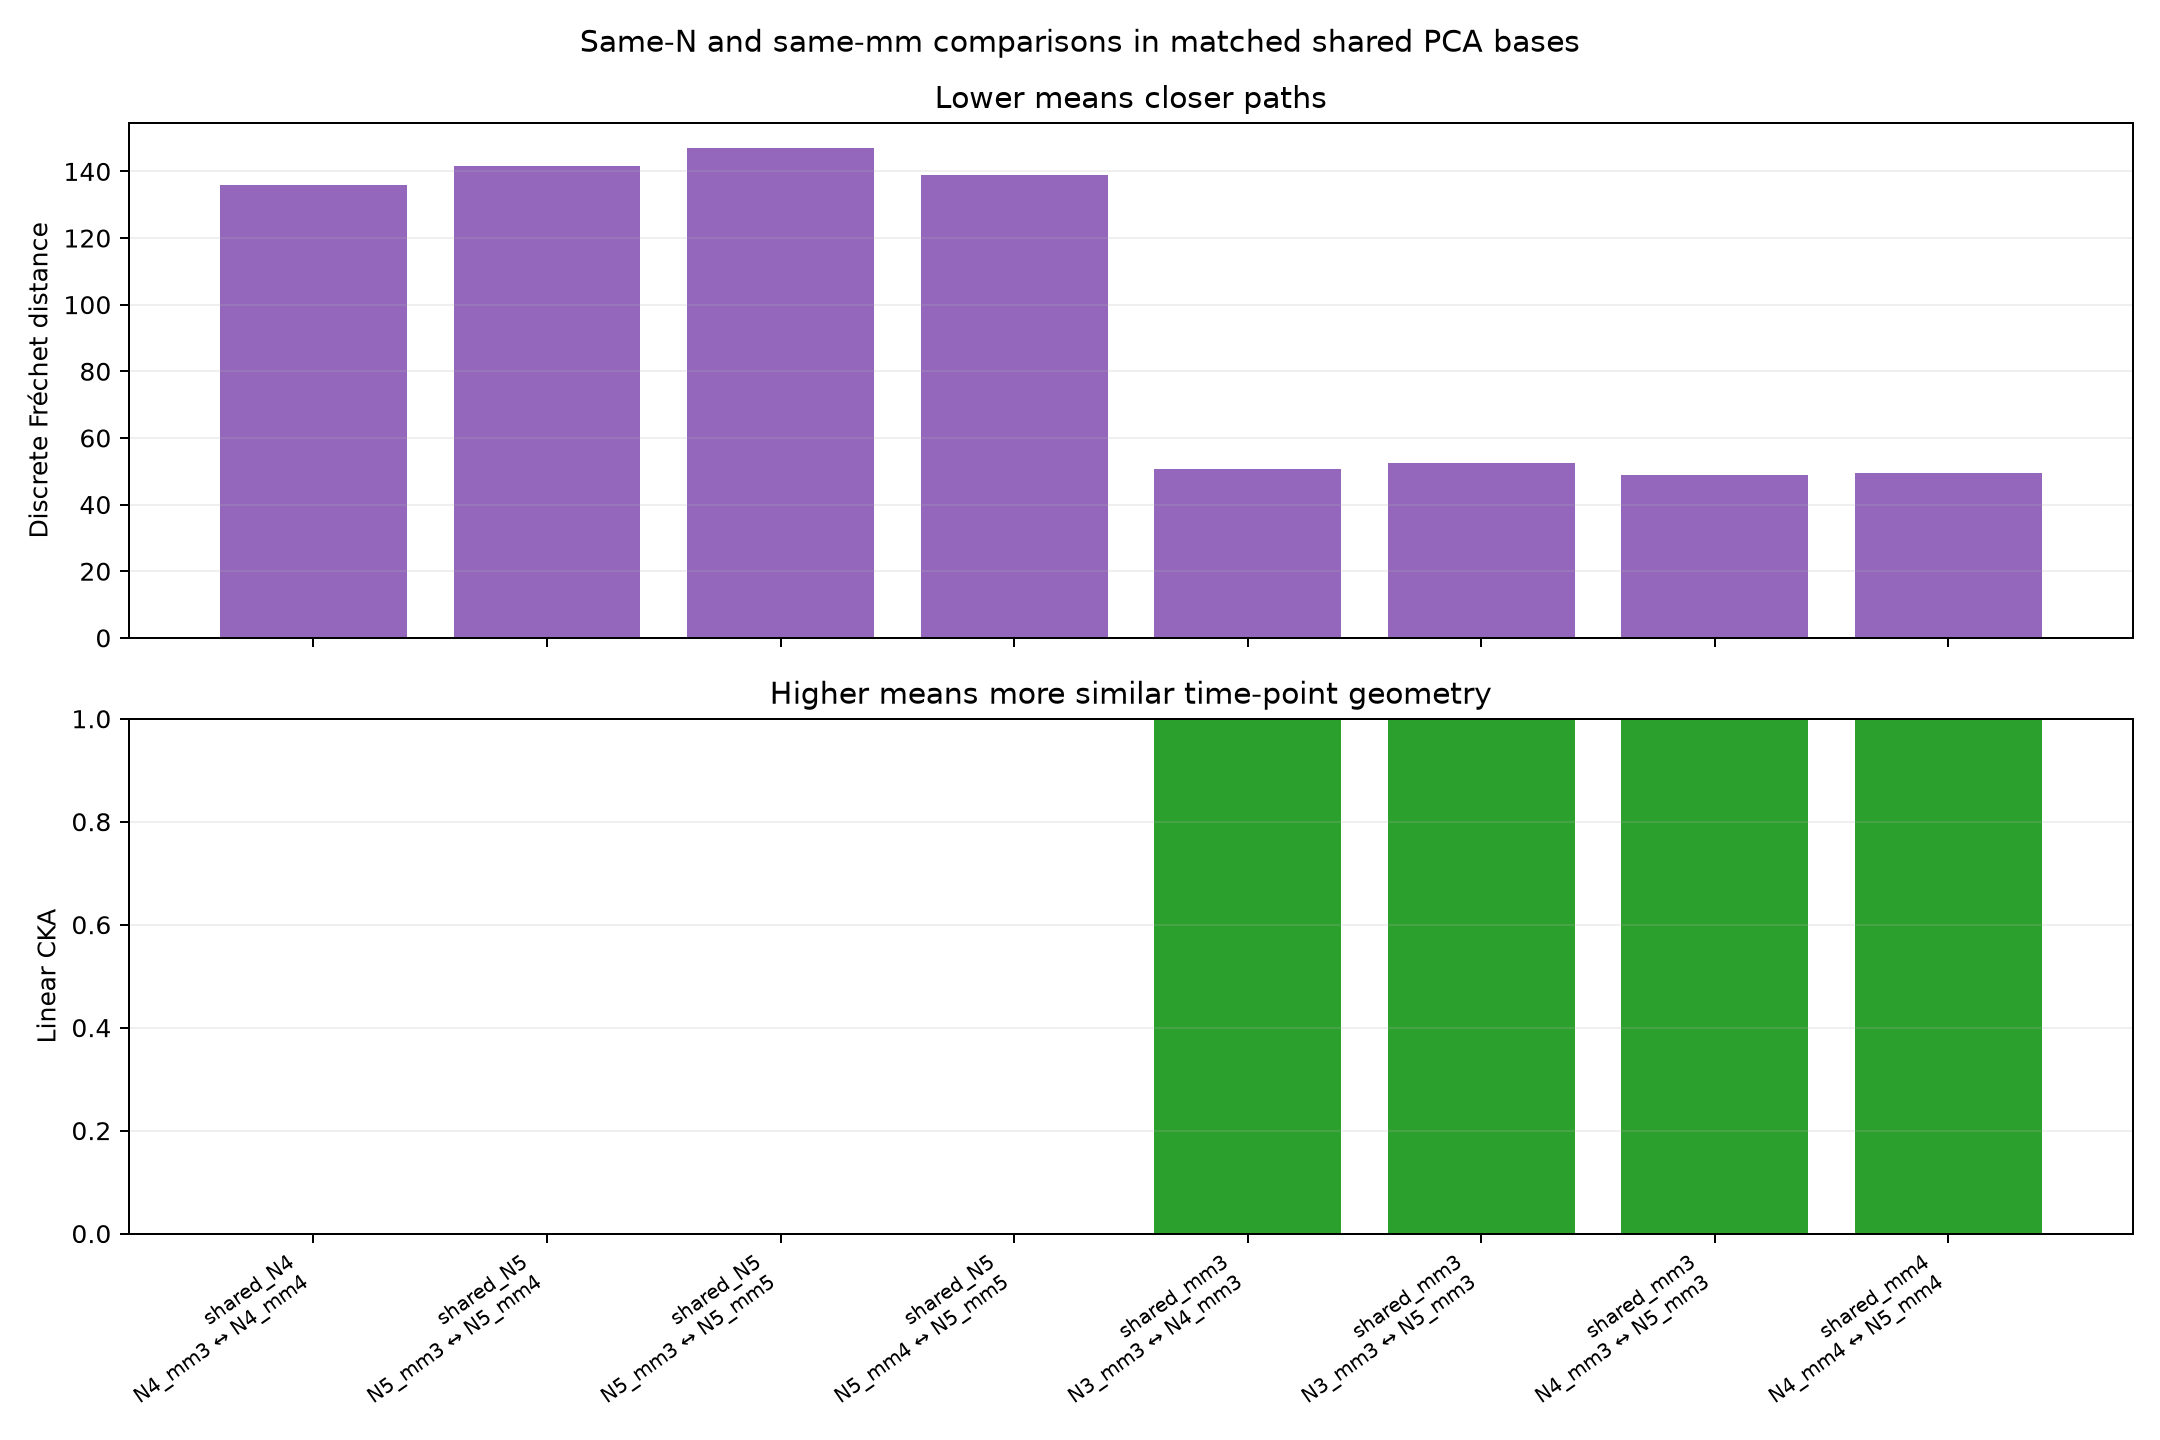

In [5]:
for name in ['08_complexity_relationships.png', '09_group_specific_similarity.png']:
    display(Image(filename=str(FIGURE_DIR / name), width=1100))

## 5. 結論

成功finalのaligned cosine中央値は、6/6条件でrandom reasoning nullの99%点を上回った。したがって、最終回答時に再現性の高い領域を通る `finalization corridor` は複数条件で検討に値する。一方、final直前にleave-one-trial-out corridor距離が低下したのは1/6条件であり、一様な吸引過程やattractorまでは支持しない。全条件共有PCAは50成分でも累積74.9%で、90%へ未到達だった。 PC1–3の図だけで高次元構造全体を代表させず、最大50成分の距離・類似度を併記する。

In [6]:
expected = [FIGURE_DIR / name for name in ['01_dataset_overview.png', '02_pca_explained_variance.png', '03_within_condition_pc123.png', '04_global_shared_pc123.png', '05_final_similarity_heatmaps.png', '06_corridor_approach.png', '07_final_vs_reasoning_null.png', '08_complexity_relationships.png', '09_group_specific_similarity.png']]
missing = [path for path in expected if not path.is_file()]
assert summary['trial_count'] == 600
assert not missing, missing
print('Verification passed: 600 trials, 6 cells, 9 figures.')

Verification passed: 600 trials, 6 cells, 9 figures.
